In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 1 — Download dataset CORD + lihat strukturnya
# ============================================================
!pip install -q datasets

import json
from datasets import load_dataset

# CORD = ~1000 nota Indonesia asli yang sudah dilabeli manual oleh peneliti
print("Downloading CORD-v2 ...")
ds = load_dataset("naver-clova-ix/cord-v2", split="train")
print(f"Jumlah nota di split train: {len(ds)}\n")

# Lihat 2 contoh: label terstruktur (gt_parse) + teks mentahnya
for i in range(2):
    gt = json.loads(ds[i]["ground_truth"])
    print("="*60)
    print(f"CONTOH #{i}")
    print("-"*60)
    print(">> LABEL TERSTRUKTUR (gt_parse):")
    print(json.dumps(gt["gt_parse"], indent=2, ensure_ascii=False))

    # rekonstruksi teks nota dari kata-kata yang sudah ter-OCR
    print("\n>> TEKS NOTA (gabungan kata-kata di gambar):")
    lines = []
    for line in gt.get("valid_line", []):
        lines.append(" ".join(w["text"] for w in line["words"]))
    print("\n".join(lines))
    print()

README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…): reconstructing file:   0%|          |  0.00B /  490MB            

data/train-00000-of-00004-b4aaeceff1d90e(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-7dbbe248962764(…): reconstructing file:   0%|          |  0.00B /  441MB            

...

data/test-00000-of-00001-9c204eb3f4e1179(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Jumlah nota di split train: 800

CONTOH #0
------------------------------------------------------------
>> LABEL TERSTRUKTUR (gt_parse):
{
  "menu": [
    {
      "nm": "Nasi Campur Bali",
      "cnt": "1 x",
      "price": "75,000"
    },
    {
      "nm": "Bbk Bengil Nasi",
      "cnt": "1 x",
      "price": "125,000"
    },
    {
      "nm": "MilkShake Starwb",
      "cnt": "1 x",
      "price": "37,000"
    },
    {
      "nm": "Ice Lemon Tea",
      "cnt": "1 x",
      "price": "24,000"
    },
    {
      "nm": "Nasi Ayam Dewata",
      "cnt": "1 x",
      "price": "70,000"
    },
    {
      "nm": "Free Ice Tea",
      "cnt": "3 x",
      "price": "0"
    },
    {
      "nm": "Organic Green Sa",
      "cnt": "1 x",
      "price": "65,000"
    },
    {
      "nm": "Ice Tea",
      "cnt": "1 x",
      "price": "18,000"
    },
    {
      "nm": "Ice Orange",
      "cnt": "1 x",
      "price": "29,000"
    },
    {
      "nm": "Ayam Suir Bali",
      "cnt": "1 x",
      "price": "85,

In [ ]:
# ============================================================
# CELL 2 — Konversi CORD ke format target kita (train/val/test)
# ============================================================
import re, json
from datasets import load_dataset

def parse_int(s):
    """Ambil semua digit jadi integer. '75,000'->75000, '40,000.'->40000."""
    if s is None: return 0
    digits = re.sub(r'\D', '', str(s))
    return int(digits) if digits else 0

def parse_cnt(s):
    """Ambil angka qty. '1 x'->1, '3 x'->3. Default 1."""
    if s is None: return 1
    m = re.search(r'\d+', str(s))
    return int(m.group()) if m else 1

def cord_to_target(gt_parse):
    """gt_parse CORD -> string target format kanonik kita."""
    menu = gt_parse.get("menu", [])
    if isinstance(menu, dict):      # CORD kadang simpan 1 item sebagai dict
        menu = [menu]
    lines = []
    for m in menu:
        if not isinstance(m, dict): continue
        nm = m.get("nm")
        if nm is None: continue
        lines.append(f"ITEM: {str(nm).strip()} | {parse_int(m.get('price'))} | {parse_cnt(m.get('cnt'))}")
    sub = gt_parse.get("sub_total", {})
    if isinstance(sub, dict):
        service, tax, discount = (parse_int(sub.get('service_price')),
                                  parse_int(sub.get('tax_price')),
                                  parse_int(sub.get('discount_price')))
    else:
        service = tax = discount = 0
    lines += [f"SERVICE: {service}", f"TAX: {tax}", f"DISCOUNT: {discount}"]
    return "\n".join(lines)

def reconstruct_input(gt):
    """Susun ulang teks nota dari kata-kata yang sudah ter-OCR di CORD."""
    out = []
    for line in gt.get("valid_line", []):
        txt = " ".join(w.get("text", "") for w in line.get("words", [])).strip()
        if txt: out.append(txt)
    return "\n".join(out)

def convert_split(split_name, out_path):
    ds = load_dataset("naver-clova-ix/cord-v2", split=split_name)
    n_ok = n_skip = 0
    with open(out_path, "w", encoding="utf-8") as f:
        for ex in ds:
            try:
                gt = json.loads(ex["ground_truth"])
                target = cord_to_target(gt["gt_parse"])
                inp = reconstruct_input(gt)
                if not inp or "ITEM:" not in target:
                    n_skip += 1; continue
                f.write(json.dumps({"input": inp, "target": target}, ensure_ascii=False) + "\n")
                n_ok += 1
            except Exception:
                n_skip += 1
    print(f"  {split_name:12s}: {n_ok} ok, {n_skip} dilewati  ->  {out_path}")
    return n_ok

print("Mengonversi CORD ke format kita ...")
convert_split("train",      "cord_train.jsonl")
convert_split("validation", "cord_val.jsonl")
convert_split("test",       "cord_test.jsonl")

# Tampilkan 1 contoh hasil konversi untuk verifikasi
print("\n" + "="*60)
print("CONTOH HASIL KONVERSI (1 nota):")
with open("cord_train.jsonl") as f:
    ex = json.loads(f.readline())
print("\n--- INPUT (teks CORD) ---\n" + ex["input"][:500])
print("\n--- TARGET (format kita) ---\n" + ex["target"])

Mengonversi CORD ke format kita ...
  train       : 795 ok, 5 dilewati  ->  cord_train.jsonl
  validation  : 100 ok, 0 dilewati  ->  cord_val.jsonl
  test        : 100 ok, 0 dilewati  ->  cord_test.jsonl

CONTOH HASIL KONVERSI (1 nota):

--- INPUT (teks CORD) ---
1 x
Nasi Campur Bali
75,000
1 x
Bbk Bengil Nasi
125,000
1 x
MilkShake Starwb
37,000
1 x
Ice Lemon Tea
24,000
1 x
Nasi Ayam Dewata
70,000
3 x
Free Ice Tea
0
1 x
Organic Green Sa
65,000
1 x
Ice Tea
18,000
1 x
Ice Orange
29,000
1 x
Ayam Suir Bali
85,000
2 x
Tahu Goreng
36,000
2 x
Tempe Goreng
36,000
1 x
Tahu Telor Asin
40,000.
1 x
Nasi Goreng Samb
70,000
3 x
Bbk Panggang Sam
366,000
1 x
Ayam Sambal Hija
92,000
2 x
Hot Tea
44,000
1 x
Ice Kopi
32,000
1 x
Tahu Telor Asin
40,000
1 x
Free Ice Tea
0
1 x


--- TARGET (format kita) ---
ITEM: Nasi Campur Bali | 75000 | 1
ITEM: Bbk Bengil Nasi | 125000 | 1
ITEM: MilkShake Starwb | 37000 | 1
ITEM: Ice Lemon Tea | 24000 | 1
ITEM: Nasi Ayam Dewata | 70000 | 1
ITEM: Free Ice Tea | 0 | 3
ITEM: 

In [ ]:
# ============================================================
# CELL 3 (v3) — qty fix + header/garis variatif
# ============================================================
import json, random
random.seed(42)

MAKANAN = [
    ("Nasi Goreng Spesial",28000,55000),("Mie Goreng Jawa",25000,48000),
    ("Ayam Goreng Kremes",30000,60000),("Sate Ayam",35000,65000),
    ("Gado-Gado",22000,40000),("Soto Ayam",25000,45000),("Bakso Urat",25000,50000),
    ("Nasi Campur",30000,58000),("Capcay Kuah",35000,70000),
    ("Sup Asparagus Kepiting",80000,160000),("Beef Noodle",45000,75000),
    ("Fried Sotong",50000,90000),("Ikan Bakar",55000,120000),
    ("Cumi Goreng Tepung",55000,95000),("Sapi Lada Hitam",65000,130000),
    ("Nasi Putih",8000,15000),("Kwetiau Goreng",35000,60000),
    ("Pangsit Goreng",25000,45000),("Lumpia Semarang",20000,40000),
    ("Tahu Telur",22000,42000),("Rawon Daging",38000,70000),
    ("Rendang Sapi",45000,85000),("Ayam Penyet",28000,52000),("Pecel Lele",22000,42000),
    ("Dim Sum Ayam",28000,55000),("Siomay Bandung",22000,45000),
    ("Tom Yum Seafood",60000,120000),("Fu Yung Hai",40000,75000),
    ("Nasi Uduk Komplit",25000,48000),("Bebek Goreng",40000,75000),
    ("Kepiting Saus Padang",120000,280000),("Udang Galah Bakar",90000,200000),
    ("Cap Cay Goreng",40000,75000),("Sapo Tahu Seafood",55000,110000),
    ("Milk Shake Strawberry",30000,45000),("Beef Steak Black Pepper",90000,180000),
]
MINUMAN = [
    ("Es Teh Manis",8000,18000),("Thai Tea",18000,35000),("Milo Dinosaur",22000,38000),
    ("Es Jeruk",12000,25000),("Kopi Hitam",12000,28000),("Cappuccino",25000,45000),
    ("Es Campur",20000,38000),("Jus Alpukat",22000,40000),("Jus Mangga",20000,38000),
    ("Air Mineral",6000,15000),("Teh Tawar Hangat",5000,12000),("Lemon Tea",15000,30000),
    ("Es Kelapa Muda",18000,35000),("Soda Gembira",20000,38000),("Matcha Latte",28000,48000),
    ("Coca Cola",10000,22000),("Sprite",10000,22000),("Es Cincau",15000,30000),
    ("Wedang Jahe",12000,25000),("Cendol Dawet",15000,30000),("Americano",22000,40000),
    ("Vanilla Latte",28000,48000),("Ice Lemon Tea",15000,30000),("Hot Tea",8000,18000),
]
RESTO_NAMES = ["Wel Nam Kee Chicken Rice","Moi Garden","Bakmi GM","Warung Nasi Sederhana",
    "Sushi Tei","Imperial Kitchen","Bebek Tepi Sawah","Layar Seafood","Depot Bu Rudy",
    "Soto Lamongan Cak No","Pondok Tjandra","Dapur Solo","Mie Mapan","Resto Sari Laut",
    "Holycow Steak","Zenbu House","Gubeng Pojok","RM Padang Sederhana","Kedai Kopi Tjap","Nelayan Resto"]
ADDR = ["Surabaya","Jl. Tunjungan No.5","Tunjungan Plaza 6 LT.5","Pakuwon Mall LG-21",
        "Jl. Mayjend Sungkono","Galaxy Mall 3","Jl. Raya Darmo 23","Ciputra World LG"]

def round_price(p):
    step=random.choice([500,1000,1000]); return max(step, round(p/step)*step)
def fmt(n):
    sep=random.choice(['.',',']); return f"{n:,}".replace(',',sep)

def generate_receipt():
    n=random.randint(1,9); items=[]
    for _ in range(n):
        if random.random()<0.6: name,lo,hi=random.choice(MAKANAN)
        else: name,lo,hi=random.choice(MINUMAN)
        per=round_price(random.randint(lo,hi))
        qty=random.choices([1,2,3,4],weights=[70,18,8,4])[0]
        items.append({"name":name,"qty":qty,"line_total":per*qty})
    subtotal=sum(it["line_total"] for it in items)
    scheme=random.choices(["none","tax_only","service_before_tax","service_only"],weights=[20,35,35,10])[0]
    tr=random.choice([0.10,0.11]); sr=random.choice([0.05,0.07,0.10])
    svc=tax=0
    if scheme=="tax_only": tax=round(subtotal*tr)
    elif scheme=="service_before_tax": svc=round(subtotal*sr); tax=round((subtotal+svc)*tr)
    elif scheme=="service_only": svc=round(subtotal*sr)
    disc=0
    if random.random()<0.15: disc=min(round_price(round(subtotal*random.uniform(.05,.20))), subtotal//2)
    total=subtotal+svc+tax-disc

    L=[]
    # ── HEADER VARIATIF (kadang tanpa header, kadang 1-3 baris) ──
    if random.random()>=0.15:
        L.append(random.choice(RESTO_NAMES).upper())
        if random.random()<0.4: L.append(random.choice(ADDR))
        if random.random()<0.3: L.append(random.choice(ADDR))
    # garis pemisah hanya kadang-kadang
    if random.random()<0.5: L.append("-"*random.randint(20,28))
    # ── ITEMS ──
    for it in items:
        nm=it["name"].upper() if random.random()<0.5 else it["name"]
        if it['qty']>1:
            pre=f"{it['qty']}x " if random.random()<0.5 else f"{it['qty']} "
        else:
            pre="1 " if random.random()<0.4 else ""
        pad="."*random.randint(2,6) if random.random()<0.3 else "   "
        L.append(f"{pre}{nm}{pad}{fmt(it['line_total'])}")
    # ── TOTAL SECTION ──
    if random.random()<0.6: L.append("-"*random.randint(20,28))
    L.append(f"{random.choice(['SUBTOTAL','Subtotal','Sub Total'])}   {fmt(subtotal)}")
    if svc>0: L.append(f"{random.choice(['SC','Service Charge','Service'])}   {fmt(svc)}")
    if tax>0: L.append(f"{random.choice([f'PPN {int(tr*100)}%',f'PB1 {int(tr*100)}%',f'Pajak {int(tr*100)}%'])}   {fmt(tax)}")
    if disc>0: L.append(f"{random.choice(['Diskon','DISCOUNT','Potongan'])}   {fmt(disc)}")
    if random.random()<0.6: L.append("-"*random.randint(20,28))
    L.append(f"{random.choice(['TOTAL','Total','Grand Total'])}   {fmt(total)}")
    if random.random()<0.4: L.append(random.choice(["TERIMA KASIH","THANK YOU"]))

    T=[f"ITEM: {it['name']} | {it['line_total']} | {it['qty']}" for it in items]
    T+=[f"SERVICE: {svc}", f"TAX: {tax}", f"DISCOUNT: {disc}"]
    return "\n".join(L), "\n".join(T)

N_SYNTH = 8000
with open("synthetic_clean.jsonl","w",encoding="utf-8") as f:
    for _ in range(N_SYNTH):
        c,t=generate_receipt()
        f.write(json.dumps({"input":c,"target":t},ensure_ascii=False)+"\n")
print(f"OK -> {N_SYNTH} nota sintetis (v3: header variatif) ditulis")

OK -> 8000 nota sintetis (v3: header variatif) ditulis


In [ ]:
# ============================================================
# CELL 4 — Suntik noise CRNN + gabung CORD & sintetis -> dataset final
# ============================================================
import json, random
random.seed(42)

# --- fungsi noise (recoverable utk angka, lebih luas utk teks) ---
DIGIT={'0':['O','o','Q'],'1':['I','l','i'],'2':['Z','z'],'5':['S','s'],'6':['G','b'],'8':['B'],'9':['g','q']}
LETTER={'O':['0','Q','C'],'o':['0','c'],'I':['1','l','L'],'l':['1','I'],'S':['5','$'],'s':['5'],
        'B':['8','R'],'G':['6','C'],'Z':['2'],'E':['F','B'],'C':['G','O'],'U':['V','Y'],
        'N':['M','H'],'D':['O','0'],'A':['4']}
def corrupt_num(tok):
    ch=list(tok); n=1 if len(ch)<=3 else random.randint(1,2)
    for i in random.sample(range(len(ch)),min(n,len(ch))):
        if ch[i] in DIGIT: ch[i]=random.choice(DIGIT[ch[i]])
    return ''.join(ch)
def corrupt_txt(tok):
    if len(tok)<2: return tok
    ch=list(tok); m=random.choice(['sub','sub','drop','swap','case']); i=random.randrange(len(ch))
    if m=='sub': ch[i]=random.choice(LETTER[ch[i]]) if ch[i] in LETTER else random.choice('abcdefghijklmnopqrstuvwxyz')
    elif m=='drop' and len(ch)>3: del ch[i]
    elif m=='swap' and len(ch)>2 and i<len(ch)-1: ch[i],ch[i+1]=ch[i+1],ch[i]
    elif m=='case': ch[i]=ch[i].swapcase()
    return ''.join(ch)
def add_noise(text, rate=0.12):
    out=[]
    for line in text.split('\n'):
        toks=[]
        for tok in line.split(' '):
            if tok and random.random()<rate:
                dc=sum(c.isdigit() for c in tok)
                toks.append(corrupt_num(tok) if dc>=max(1,len(tok)//2) else corrupt_txt(tok))
            else: toks.append(tok)
        out.append(' '.join(toks))
    return '\n'.join(out)

def load(p): return [json.loads(l) for l in open(p, encoding="utf-8")]

synth     = load("synthetic_clean.jsonl")
cord_tr   = load("cord_train.jsonl")
cord_val  = load("cord_val.jsonl")

# CORD diulang beberapa kali dgn noise berbeda tiap kali (augmentasi data nyata)
CORD_REPEAT = 3
train=[]
for ex in synth:
    train.append({"input":add_noise(ex["input"]),"target":ex["target"]})
for _ in range(CORD_REPEAT):
    for ex in cord_tr:
        train.append({"input":add_noise(ex["input"]),"target":ex["target"]})
random.shuffle(train)

val=[{"input":add_noise(ex["input"]),"target":ex["target"]} for ex in cord_val]

with open("train_final.jsonl","w",encoding="utf-8") as f:
    for ex in train: f.write(json.dumps(ex,ensure_ascii=False)+"\n")
with open("val_final.jsonl","w",encoding="utf-8") as f:
    for ex in val: f.write(json.dumps(ex,ensure_ascii=False)+"\n")

# statistik panjang (buat setting model nanti)
def wlen(s): return len(s.split())
max_in  = max(wlen(ex["input"])  for ex in train)
max_out = max(wlen(ex["target"]) for ex in train)
print(f"sintetis={len(synth)}, CORD={len(cord_tr)}x{CORD_REPEAT}")
print(f"TRAIN total = {len(train)}  |  VAL = {len(val)}")
print(f"panjang max (kata): input={max_in}, target={max_out}")
print("\n=== 1 contoh dataset final ===")
print("INPUT:\n"+train[0]["input"])
print("\nTARGET:\n"+train[0]["target"])

sintetis=8000, CORD=795x3
TRAIN total = 10385  |  VAL = 100
panjang max (kata): input=135, target=174

=== 1 contoh dataset final ===
INPUT:
KEDAI KOPI TJAP
----------------------------
2 $oto Ayam   68,000
z JUS ALPUKAT   58,000
Vanilla Latte   31.000
1 BEEF NOODLE   55,000
1 Sapo Tahu Seafood...86,000
2x BEEF STEAK BLACK PEPPER   272.000
------------------------
Subtotal   570.000
PPN 10%   57.000
-----------------------
Grand Total   627,000
THANK YOY

TARGET:
ITEM: Soto Ayam | 68000 | 2
ITEM: Jus Alpukat | 58000 | 2
ITEM: Vanilla Latte | 31000 | 1
ITEM: Beef Noodle | 55000 | 1
ITEM: Sapo Tahu Seafood | 86000 | 1
ITEM: Beef Steak Black Pepper | 272000 | 2
SERVICE: 0
TAX: 57000
DISCOUNT: 0


In [ ]:
# ============================================================
# CELL 5 — Setup model + tokenisasi data (jalankan di GPU)
# ============================================================
!pip install -q transformers datasets accelerate sentencepiece

import json, torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("GPU aktif:", torch.cuda.is_available())   # HARUS True

# Base model open-source dari HuggingFace (BUKAN OpenAI). Kecil & cepat.
MODEL_NAME = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

def load_jsonl(p): return [json.loads(l) for l in open(p, encoding="utf-8")]
train_data = load_jsonl("train_final.jsonl")
val_data   = load_jsonl("val_final.jsonl")

PREFIX  = "ekstrak nota: "
MAX_IN  = 768
MAX_OUT = 512

def preprocess(batch):
    inputs = [PREFIX + x for x in batch["input"]]
    model_inputs = tokenizer(inputs, max_length=MAX_IN, truncation=True)
    labels = tokenizer(text_target=batch["target"], max_length=MAX_OUT, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_ds = Dataset.from_list(train_data).map(preprocess, batched=True, remove_columns=["input","target"])
val_ds   = Dataset.from_list(val_data).map(preprocess,   batched=True, remove_columns=["input","target"])

# Cek panjang token aktual (mastiin nggak ada yang kepotong)
il = [len(x) for x in train_ds["input_ids"]]
ol = [len(x) for x in train_ds["labels"]]
print(f"Train={len(train_ds)}  Val={len(val_ds)}")
print(f"Token INPUT : max={max(il)}  rata2={sum(il)//len(il)}  (limit {MAX_IN})")
print(f"Token TARGET: max={max(ol)}  rata2={sum(ol)//len(ol)}  (limit {MAX_OUT})")

GPU aktif: True


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Map:   0%|          | 0/10385 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Train=10385  Val=100
Token INPUT : max=280  rata2=95  (limit 768)
Token TARGET: max=349  rata2=77  (limit 512)


In [ ]:
# ============================================================
# CELL 6 (FINAL) — Latih model + simpan ke Google Drive
# ============================================================
from transformers import (DataCollatorForSeq2Seq,
                          Seq2SeqTrainingArguments, Seq2SeqTrainer)

collator = DataCollatorForSeq2Seq(tokenizer, model=model)

args = Seq2SeqTrainingArguments(
    output_dir="bagi_model",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-4,
    weight_decay=0.01,
    warmup_steps=250,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=100,
    fp16=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    processing_class=tokenizer,
)

trainer.train()

# simpan PERMANEN ke Google Drive (aman walau runtime reset)
SAVE_DIR = "/content/drive/MyDrive/bagi_model_final"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("\nSELESAI! Model tersimpan PERMANEN di:", SAVE_DIR)

Epoch,Training Loss,Validation Loss
1,0.110363,0.196457
2,0.070427,0.157033
3,0.050546,0.146036
4,0.040678,0.145292


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SELESAI! Model tersimpan PERMANEN di: /content/drive/MyDrive/bagi_model_final


In [ ]:
# ============================================================
# CELL 7 (FINAL) — Load model dari Drive + tes di nota asli
# ============================================================
import torch, re, json
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SAVE_DIR = "/content/drive/MyDrive/bagi_model_final"
model = AutoModelForSeq2SeqLM.from_pretrained(SAVE_DIR).to("cuda").eval()
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
PREFIX = "ekstrak nota: "

@torch.no_grad()
def run_model(text):
    enc = tokenizer(PREFIX + text, return_tensors="pt", max_length=768, truncation=True).to("cuda")
    out = model.generate(**enc, max_length=512, num_beams=4, early_stopping=True)
    return tokenizer.decode(out[0], skip_special_tokens=True)

def parse_output(s):
    items = []
    for m in re.finditer(r"ITEM:\s*(.+?)\s*\|\s*(\d+)\s*\|\s*(\d+)", s):
        items.append({"name": m.group(1).strip(),
                      "line_total": int(m.group(2)), "qty": int(m.group(3))})
    def grab(k):
        mm = re.search(rf"{k}:\s*(\d+)", s); return int(mm.group(1)) if mm else 0
    return {"items": items, "service": grab("SERVICE"),
            "tax": grab("TAX"), "discount": grab("DISCOUNT")}

# klasifikasi kategori via keyword (dikerjakan Python, bukan model)
MINUMAN_KW = ["tea","teh","kopi","coffee","jus","juice","ice","es ","milk","latte",
              "cappu","americano","soda","cola","sprite","lemon","orange","water",
              "air ","wedang","cendol","matcha","dawet","milo","float","mocktail","frappe"]
def classify(name):
    low = " " + name.lower() + " "
    return "minuman" if any(k in low for k in MINUMAN_KW) else "makanan"

def show(text, title):
    print("="*60); print(title); print("-"*60)
    raw = run_model(text)
    print(">> OUTPUT MENTAH MODEL:\n" + raw)
    p = parse_output(raw)
    print("\n>> HASIL TERSTRUKTUR (+ pembagian harga & kategori oleh Python):")
    for it in p["items"]:
        per = it["line_total"] // it["qty"] if it["qty"] else it["line_total"]
        print(f"   - {it['name']:25s} x{it['qty']}  total {it['line_total']:>8}  "
              f"= {per:>7}/porsi  [{classify(it['name'])}]")
    print(f"   Service={p['service']}  Tax={p['tax']}  Diskon={p['discount']}")

# --- TES 1 & 2: nota CORD test (data asli yang TIDAK dilihat saat latih) ---
cord_test = [json.loads(l) for l in open("cord_test.jsonl", encoding="utf-8")]
show(cord_test[0]["input"], "TES 1 — Nota CORD test #0")
show(cord_test[5]["input"], "TES 2 — Nota CORD test #5")

# --- TES 3: nota ASLI Wel Nam Kee (diketik dari fotomu) ---
nota_wel_nam_kee = """WEL NAM KEE
CHICKEN RICE
Tunjungan Plaza
1 BEEF NOODLE 52,000
1 FRIED SOTONG 58,000
3 THAI TEA 75,000
1 MILO DINOSAUR 28,000
SUBTOTAL 213,000
SC 14,910
PPN 10% 22,791
TOTAL 250,701"""
show(nota_wel_nam_kee, "TES 3 — Nota ASLI Wel Nam Kee (dari fotomu)")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

TES 1 — Nota CORD test #0
------------------------------------------------------------
>> OUTPUT MENTAH MODEL:
ITEM: -TICKET CP | 60000 | 2 SERVICE: 0 TAX: 5455 DISCOUNT: 0

>> HASIL TERSTRUKTUR (+ pembagian harga & kategori oleh Python):
   - -TICKET CP                x2  total    60000  =   30000/porsi  [makanan]
   Service=0  Tax=5455  Diskon=0
TES 2 — Nota CORD test #5
------------------------------------------------------------
>> OUTPUT MENTAH MODEL:
ITEM: TRAD KY TOAST CARTE | 28182 | 1 SERVICE: 0 TAX: 2818 DISCOUNT: 0

>> HASIL TERSTRUKTUR (+ pembagian harga & kategori oleh Python):
   - TRAD KY TOAST CARTE       x1  total    28182  =   28182/porsi  [makanan]
   Service=0  Tax=2818  Diskon=0
TES 3 — Nota ASLI Wel Nam Kee (dari fotomu)
------------------------------------------------------------
>> OUTPUT MENTAH MODEL:
ITEM: Beef Noodle | 52000 | 1 ITEM: Fried Sotong | 58000 | 1 ITEM: Thai Tea | 75000 | 3 ITEM: Milo Dinosaur | 28000 | 1 SERVICE: 14910 TAX: 22991 DISCOUNT: 0

>> 

In [ ]:
# ============================================================
# CELL 8 — Evaluasi akurasi di 100 nota CORD test
# ============================================================
import re, json
from collections import Counter

def parse_struct(s):
    items=[]
    for m in re.finditer(r"ITEM:\s*(.+?)\s*\|\s*(\d+)\s*\|\s*(\d+)", s):
        items.append((m.group(1).strip().lower(), int(m.group(2)), int(m.group(3))))
    def grab(k):
        mm=re.search(rf"{k}:\s*(\d+)", s); return int(mm.group(1)) if mm else 0
    return items, grab("SERVICE"), grab("TAX"), grab("DISCOUNT")

cord_test=[json.loads(l) for l in open("cord_test.jsonl",encoding="utf-8")]
n=len(cord_test)
cnt_match=price_match=tax_ok=svc_ok=disc_ok=0
item_tp=item_fp=item_fn=0

print("Mengevaluasi 100 nota (sekitar 1-2 menit)...\n")
for i,ex in enumerate(cord_test):
    raw=run_model(ex["input"])
    p_items,p_svc,p_tax,p_disc=parse_struct(raw)
    g_items,g_svc,g_tax,g_disc=parse_struct(ex["target"])
    if len(p_items)==len(g_items): cnt_match+=1
    if sorted(x[1] for x in p_items)==sorted(x[1] for x in g_items): price_match+=1
    tax_ok+=(p_tax==g_tax); svc_ok+=(p_svc==g_svc); disc_ok+=(p_disc==g_disc)
    gset=sorted((x[1],x[2]) for x in g_items); pset=sorted((x[1],x[2]) for x in p_items)
    gc,pc=Counter(gset),Counter(pset); inter=sum((gc&pc).values())
    item_tp+=inter; item_fp+=len(pset)-inter; item_fn+=len(gset)-inter
    if i<5:
        print(f"--- #{i} ---\nPRED: {raw[:160]}\nGOLD: {ex['target'][:160]}\n")

prec=item_tp/(item_tp+item_fp) if item_tp+item_fp else 0
rec =item_tp/(item_tp+item_fn) if item_tp+item_fn else 0
f1=2*prec*rec/(prec+rec) if prec+rec else 0
print("="*55)
print("METRIK (100 nota CORD test, data yang TIDAK dilihat saat latih)")
print("="*55)
print(f"Jumlah item per nota tepat : {cnt_match}/{n}")
print(f"Semua harga dalam nota cocok: {price_match}/{n}")
print(f"Item (harga+qty) F1        : {f1:.1%}  (precision {prec:.1%}, recall {rec:.1%})")
print(f"Tax tepat                  : {tax_ok}/{n}")
print(f"Service tepat              : {svc_ok}/{n}")
print(f"Discount tepat             : {disc_ok}/{n}")

Mengevaluasi 100 nota (sekitar 1-2 menit)...

--- #0 ---
PRED: ITEM: -TICKET CP | 60000 | 2 SERVICE: 0 TAX: 5455 DISCOUNT: 0
GOLD: ITEM: -TICKET CP | 60000 | 2
SERVICE: 0
TAX: 5455
DISCOUNT: 60000

--- #1 ---
PRED: ITEM: J.STB PROMO | 17500 | 1 ITEM: Y.BAT | 46000 | 1 ITEM: Y.BASO PROM | 27500 | 1 SERVICE: 0 TAX: 0 DISCOUNT: 0
GOLD: ITEM: J.STB PROMO | 17500 | 1
ITEM: Y.B.BAT | 46000 | 1
ITEM: Y.BASO PROM | 27500 | 1
SERVICE: 0
TAX: 0
DISCOUNT: 0

--- #2 ---
PRED: ITEM: JASMINE MT ( L ) | 24000 | 1 SERVICE: 0 TAX: 0 DISCOUNT: 0
GOLD: ITEM: JASMINE MT ( L ) | 24000 | 1
SERVICE: 0
TAX: 0
DISCOUNT: 0

--- #3 ---
PRED: ITEM: DONAT GULA | 11000 | 1 SERVICE: 0 TAX: 0 DISCOUNT: 0
GOLD: ITEM: DONAT GULA | 11000 | 1
SERVICE: 0
TAX: 0
DISCOUNT: 0

--- #4 ---
PRED: ITEM: ICE BLACKCOFFE | 82000 | 2 ITEM: AVOCADO COFFEE | 61000 | 1 ITEM: CHIKEN KATSU FF | 51000 | 1 SERVICE: 0 TAX: 0 DISCOUNT: 19400
GOLD: ITEM: ICE BLACKCOFFE | 82000 | 2
ITEM: AVOCADO COFFEE | 61000 | 1
ITEM: CHIKEN KATSU FF | 51000

In [ ]:
# ============================================================
# CELL 9 (FIX) — Number snapping + ukur dampak (dengan vs tanpa)
# ============================================================
import re, json
from collections import Counter

def edit_distance(a, b):
    m,n=len(a),len(b); dp=list(range(n+1))
    for i in range(1,m+1):
        prev=dp[0]; dp[0]=i
        for j in range(1,n+1):
            cur=dp[j]; dp[j]=min(dp[j]+1, dp[j-1]+1, prev+(a[i-1]!=b[j-1])); prev=cur
    return dp[n]

LOOKALIKE=str.maketrans({'O':'0','o':'0','Q':'0','I':'1','l':'1','S':'5','s':'5','B':'8','G':'6','Z':'2'})

def input_numbers(text):
    clean=text.translate(LOOKALIKE); nums=set()
    for m in re.finditer(r'\d[\d.,]*', clean):
        d=re.sub(r'\D','',m.group())
        if d and int(d)>=1000: nums.add(int(d))   # FIX: hanya nominal >=1000
    return nums

def snap(pred, inums):
    if pred < 1000: return pred                    # FIX: jangan snap 0/qty/persen
    if pred in inums or not inums: return pred
    ps=str(pred); best=None; bd=99
    for x in inums:
        xs=str(x)
        if abs(len(xs)-len(ps))>1: continue
        d=edit_distance(ps,xs)
        if d<bd: bd=d; best=x
    return best if best is not None and bd<=2 else pred

def parse_struct(s):
    items=[]
    for m in re.finditer(r"ITEM:\s*(.+?)\s*\|\s*(\d+)\s*\|\s*(\d+)", s):
        items.append([m.group(1).strip().lower(), int(m.group(2)), int(m.group(3))])
    def grab(k):
        mm=re.search(rf"{k}:\s*(\d+)", s); return int(mm.group(1)) if mm else 0
    return items, grab("SERVICE"), grab("TAX"), grab("DISCOUNT")

cord_test=[json.loads(l) for l in open("cord_test.jsonl",encoding="utf-8")]
print("Menjalankan model di 100 nota (sekali saja)...")
preds=[run_model(ex["input"]) for ex in cord_test]   # cache prediksi

def evaluate(use_snap):
    price=tax_ok=svc_ok=disc_ok=0; tp=fp=fn=0
    for ex,raw in zip(cord_test,preds):
        items,svc,tax,disc=parse_struct(raw)
        g_items,g_svc,g_tax,g_disc=parse_struct(ex["target"])
        if use_snap:
            inums=input_numbers(ex["input"])
            for it in items: it[1]=snap(it[1],inums)
            svc=snap(svc,inums); tax=snap(tax,inums); disc=snap(disc,inums)
        if sorted(x[1] for x in items)==sorted(x[1] for x in g_items): price+=1
        tax_ok+=(tax==g_tax); svc_ok+=(svc==g_svc); disc_ok+=(disc==g_disc)
        gset=sorted((x[1],x[2]) for x in g_items); pset=sorted((x[1],x[2]) for x in items)
        gc,pc=Counter(gset),Counter(pset); inter=sum((gc&pc).values())
        tp+=inter; fp+=len(pset)-inter; fn+=len(gset)-inter
    prec=tp/(tp+fp) if tp+fp else 0; rec=tp/(tp+fn) if tp+fn else 0
    f1=2*prec*rec/(prec+rec) if prec+rec else 0
    return price,tax_ok,svc_ok,disc_ok,f1

a=evaluate(False); b=evaluate(True)
print("\n"+"="*46)
print(f"{'Metrik':22s}{'tanpa':>10}{'+snap':>12}")
print("="*46)
print(f"{'Semua harga cocok':22s}{a[0]:>9}%{b[0]:>11}%")
print(f"{'Tax tepat':22s}{a[1]:>9}%{b[1]:>11}%")
print(f"{'Service tepat':22s}{a[2]:>9}%{b[2]:>11}%")
print(f"{'Discount tepat':22s}{a[3]:>9}%{b[3]:>11}%")
print(f"{'Item F1':22s}{a[4]:>9.1%}{b[4]:>11.1%}")

Menjalankan model di 100 nota (sekali saja)...

Metrik                     tanpa       +snap
Semua harga cocok            84%         86%
Tax tepat                    94%         98%
Service tepat                99%        100%
Discount tepat               99%         99%
Item F1                   88.3%      91.9%


In [ ]:
# ============================================================
# CELL 10 — Upload model ke HuggingFace Hub
# ============================================================
from huggingface_hub import notebook_login
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

notebook_login()   # muncul kotak input -> paste token WRITE-mu, klik Login

In [ ]:
# ============================================================
# CELL 11 — Push model ke repo
# ============================================================
SAVE_DIR = "/content/drive/MyDrive/bagi_model_final"
REPO = "pipluptine/bagi-tagihan-parser"   # <-- GANTI USERNAME dgn username HF-mu

model = AutoModelForSeq2SeqLM.from_pretrained(SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)

model.push_to_hub(REPO)
tokenizer.push_to_hub(REPO)
print(f"SELESAI! Cek di: https://huggingface.co/{REPO}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pr8u9sz/model.safetensors:   0%|          |  552kB /  242MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

SELESAI! Cek di: https://huggingface.co/pipluptine/bagi-tagihan-parser


In [ ]:
# ============================================================
# CELL OCR-1 — Validasi: CRNN-mu baca 1 baris bersih dari CORD
# ============================================================
# Pastikan Drive ke-mount
from google.colab import drive
drive.mount('/content/drive')

!pip install -q openvino

import numpy as np, json
from openvino import Core
from datasets import load_dataset

# >>> SESUAIKAN ke lokasi file CRNN-mu (.bin harus di folder yang sama) <
CRNN_XML = "/content/drive/MyDrive/crnn_model.xml"

ie = Core()
crnn = ie.compile_model(ie.read_model(CRNN_XML), "CPU")
print("CRNN ke-load OK\n")

CHARS = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz .,:-/()'
BLANK = len(CHARS)
def decode_crnn(image_pil):
    img = image_pil.convert('L').resize((256, 32))
    arr = np.array(img, dtype=np.float32)
    arr = (arr/255.0 - 0.5)/0.5
    arr = arr[np.newaxis, np.newaxis, :, :]
    req = crnn.create_infer_request()
    req.infer({crnn.input(0): arr})
    out = req.get_output_tensor(0).data
    idx = np.argmax(out[:,0,:], axis=1)
    chars, prev = [], BLANK
    for i in idx:
        if i != BLANK and i != prev:
            chars.append('' if i>=len(CHARS) else CHARS[i])
        prev = i
    return ''.join(chars).strip()

def word_bbox(w):
    q = w.get("quad", {})
    xs = [q.get(k,0) for k in ("x1","x2","x3","x4")]
    ys = [q.get(k,0) for k in ("y1","y2","y3","y4")]
    return min(xs), min(ys), max(xs), max(ys)

ds = load_dataset("naver-clova-ix/cord-v2", split="train")
ex = ds[0]; img = ex["image"]; gt = json.loads(ex["ground_truth"])

print("Tes CRNN di 6 baris pertama (CRNN vs kebenaran):\n")
for i, line in enumerate(gt["valid_line"][:6]):
    words = line["words"]
    xs=[]; ys=[]
    for w in words:
        x0,y0,x1,y1 = word_bbox(w); xs += [x0,x1]; ys += [y0,y1]
    crop = img.crop((min(xs), min(ys), max(xs), max(ys)))
    truth = " ".join(w["text"] for w in words)
    print(f"TRUTH: {truth}")
    print(f"CRNN : {decode_crnn(crop)}")
    print("-"*45)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 20.1 MB/s eta 0:00:00
CRNN ke-load OK



data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

data/train-00002-of-00004-688fe1305a55e5(…):   0%|          | 0.00/444M [00:00<?, ?B/s]

data/train-00003-of-00004-2d0cd200555ed7(…):   0%|          | 0.00/456M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Tes CRNN di 6 baris pertama (CRNN vs kebenaran):

TRUTH: 1 x
CRNN : 1 X
---------------------------------------------
TRUTH: Nasi Campur Bali
CRNN : eeli Camnur Bali
---------------------------------------------
TRUTH: 75,000
CRNN : 75,000
---------------------------------------------
TRUTH: 1 x
CRNN : 1 X
---------------------------------------------
TRUTH: Bbk Bengil Nasi
CRNN : Sb Bangil Nesi
---------------------------------------------
TRUTH: 125,000
CRNN : 125,000
---------------------------------------------


In [ ]:
# ============================================================
# CELL OCR-2 (v2) — crop KETAT + pisah nama/harga
# Butuh decode_crnn dari CELL OCR-1 ke-load
# ============================================================
from google.colab import files
from PIL import Image
import numpy as np, cv2, torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

PARSER="pipluptine/bagi-tagihan-parser"
ptok=AutoTokenizer.from_pretrained(PARSER)
pmodel=AutoModelForSeq2SeqLM.from_pretrained(PARSER).eval()
PREFIX="ekstrak nota: "

@torch.no_grad()
def run_parser(text):
    enc=ptok(PREFIX+text,return_tensors="pt",max_length=768,truncation=True)
    out=pmodel.generate(**enc,max_length=512,num_beams=4,early_stopping=True)
    return ptok.decode(out[0],skip_special_tokens=True)

def deskew(gray):
    th=cv2.threshold(cv2.bitwise_not(gray),0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]
    coords=np.column_stack(np.where(th>0))
    if len(coords)<50: return gray
    ang=cv2.minAreaRect(coords)[-1]; ang=-(90+ang) if ang<-45 else -ang
    if abs(ang)<0.5 or abs(ang)>20: return gray
    h,w=gray.shape
    M=cv2.getRotationMatrix2D((w//2,h//2),ang,1.0)
    return cv2.warpAffine(gray,M,(w,h),flags=cv2.INTER_CUBIC,borderValue=255)

def ocr_receipt(pil):
    gray=np.array(pil.convert('L'))
    h,w=gray.shape
    gray=cv2.resize(gray,(800,int(h*800/w)))           # normalisasi lebar 800px
    gray=deskew(gray)
    gray=cv2.createCLAHE(clipLimit=3.0,tileGridSize=(8,8)).apply(gray)   # pertajam kontras
    binar=cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,31,15)
    proj=binar.sum(axis=1)/255
    thr=max(3, proj.max()*0.12); rows=[]; start=None
    for i,v in enumerate(proj>thr):
        if v and start is None: start=i
        elif not v and start is not None:
            if i-start>=10: rows.append((max(0,start-3),min(len(proj),i+3)))
            start=None
    if start is not None: rows.append((start,len(proj)))
    lines=[]
    for s,e in rows:
        col=binar[s:e,:].sum(axis=0); cols=np.where(col>0)[0]
        if len(cols)<3: continue
        splits=[cols[0]]
        for k in range(1,len(cols)):
            if cols[k]-cols[k-1]>45: splits+=[cols[k-1],cols[k]]   # gap besar = pemisah
        splits.append(cols[-1])
        segs=[(splits[i],splits[i+1]) for i in range(0,len(splits)-1,2)]
        parts=[]
        for a,b in segs:
            if b-a>12:
                t=decode_crnn(Image.fromarray(gray[s:e, max(0,a-3):b+3])).strip()
                if t: parts.append(t)
        if parts: lines.append(" ".join(parts))
    return "\n".join(lines)

up=files.upload()
pil=Image.open(list(up.keys())[0])
ocr_text=ocr_receipt(pil)
print("="*55); print("HASIL OCR:"); print("="*55); print(ocr_text)
print("\n"+"="*55); print("HASIL PARSER:"); print("="*55); print(run_parser(ocr_text))

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Saving WhatsApp Image 2026-05-01 at 12.18.05.jpeg to WhatsApp Image 2026-05-01 at 12.18.05 (5).jpeg
HASIL OCR:
RETES

HASIL PARSER:
ITEM: RETES: 0


In [ ]:
# ============================================================
# CELL OCR-3 — Tes pipeline PENUH di gambar CORD (bersih)
# Butuh: ocr_receipt & run_parser dari OCR-2, decode_crnn dari OCR-1
# ============================================================
from datasets import load_dataset
ds = load_dataset("naver-clova-ix/cord-v2", split="test")
pil = ds[2]["image"]                       # gambar nota CORD yang bersih
ocr_text = ocr_receipt(pil)
print("="*55); print("HASIL OCR (CRNN baca gambar bersih):"); print("="*55)
print(ocr_text)
print("\n"+"="*55); print("HASIL PARSER:"); print("="*55)
print(run_parser(ocr_text))

HASIL OCR (CRNN baca gambar bersih):
Q WR
WNTUL
WW
4BDT:
WITI
SIN FBN
II WD
S NO: 100,000
SN WMW
21 Wliil

HASIL PARSER:
ITEM: WR WNTUL WW | 100000 | 1 SERVICE: 0 TAX: 0 DISCOUNT: 0


In [ ]:
# ============================================================
# CELL OCR-4 (LENGKAP) — EasyOCR detektor + CRNN + run_parser di dalam
# Butuh: decode_crnn & crnn dari CELL OCR-1
# ============================================================
!pip install -q easyocr
import easyocr, numpy as np, torch
from PIL import Image
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# --- load parser SEKALI (di dalam cell ini) ---
PARSER="pipluptine/bagi-tagihan-parser"
ptok=AutoTokenizer.from_pretrained(PARSER)
pmodel=AutoModelForSeq2SeqLM.from_pretrained(PARSER).eval()
PREFIX="ekstrak nota: "
@torch.no_grad()
def run_parser(text):
    enc=ptok(PREFIX+text,return_tensors="pt",max_length=768,truncation=True)
    out=pmodel.generate(**enc,max_length=512,num_beams=4,early_stopping=True)
    return ptok.decode(out[0],skip_special_tokens=True)

# --- detektor CRAFT via EasyOCR ---
reader = easyocr.Reader(['en'], gpu=True)

def ocr_receipt_v2(pil):
    arr = np.array(pil.convert('RGB'))
    horizontal, _ = reader.detect(arr, width_ths=0.7, ycenter_ths=0.5)
    boxes = sorted(horizontal[0], key=lambda b:(b[2], b[0]))
    lines=[]; cur=[]; cur_y=None
    for b in boxes:
        x1,x2,y1,y2=b; yc=(y1+y2)/2
        if cur_y is None or abs(yc-cur_y) < max(8,(y2-y1)*0.6):
            cur.append(b); cur_y=yc if cur_y is None else (cur_y*len(cur)+yc)/(len(cur)+1)
        else:
            lines.append(cur); cur=[b]; cur_y=yc
    if cur: lines.append(cur)
    gray = np.array(pil.convert('L'))
    out=[]
    for line in lines:
        parts=[]
        for x1,x2,y1,y2 in sorted(line, key=lambda b:b[0]):
            crop=gray[max(0,int(y1)):int(y2), max(0,int(x1)):int(x2)]
            if crop.size==0: continue
            t=decode_crnn(Image.fromarray(crop)).strip()
            if t: parts.append(t)
        if parts: out.append(" ".join(parts))
    return "\n".join(out)

# --- tes cepat ---
from datasets import load_dataset
ds=load_dataset("naver-clova-ix/cord-v2", split="test")
pil=ds[2]["image"]
txt=ocr_receipt_v2(pil)
print("="*55); print("HASIL OCR (detektor + CRNN-mu):"); print("="*55); print(txt)
print("\n"+"="*55); print("HASIL PARSER:"); print("="*55); print(run_parser(txt))

config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

HASIL OCR (detektor + CRNN-mu):
MnSMINEMT 24,000
ICONLTJELLY 4,000
SUB  T(lAI 28,000
TOTAL SALS 28,000
TOTALIILS
CASH 100,000
CHANG 12,000
Daalim: l0x

HASIL PARSER:
ITEM: MSMINEMT | 24000 | 1 ITEM: ICONLTJELLY | 4000 | 1 SERVICE: 0 TAX: 0 DISCOUNT: 0


In [ ]:
print(type(crnn))

<class 'openvino._ov_api.CompiledModel'>


In [ ]:
# ============================================================
# CELL OCR-5 — Tes pipeline penuh di FOTO HP asli
# ============================================================
from google.colab import files
from PIL import Image
up=files.upload()
pil=Image.open(list(up.keys())[0])
txt=ocr_receipt_v2(pil)
print("="*55); print("HASIL OCR:"); print("="*55); print(txt)
print("\n"+"="*55); print("HASIL PARSER:"); print("="*55); print(run_parser(txt))

Saving WhatsApp Image 2026-05-01 at 12.18.05.jpeg to WhatsApp Image 2026-05-01 at 12.18.05 (3).jpeg
HASIL OCR:
7Tgaaep
Fp
Rel HAKKA CIESE RESTURMT
Pax: T
IPARAIB BITDGE 95,000.00
SS M(BDIA BRD S 89.000.00
NMI NTGGIRMAS 65.000.00
SZ NSIRDG R6 0OIS 65.000.00
ESLBON TEA 15800.00
C EB TEHMANIS 10.800.00
ES JERUKNIPIS 14,800.00 JUBM
SB akl laenane 41,400.00
Sb Total Focd 314,000.00
29704/2026 NETTTO 355,400.00
Service 7.100.00
PP1 36.250.00
TOTAL 378.750.00
Manya((e(T( gME SUrabaya 895i61s

HASIL PARSER:
ITEM: T IPARAIB BITDGE | 950000 | 1 ITEM: SS M(BDIA BRD S | 890000 | 1 ITEM: NMI NTGGIRMAS | 6500000 | 1 ITEM: SZ NSIRDG R6 | 6500000 | 1 ITEM: ESLBON TEA | 1500000 | 1 ITEM: C EB TEHMANIS | 1080000 | 1 ITEM: JUBM SB akl laenane | 41400000 | 1 SERVICE: 710000 TAX: 36550 DISCOUNT: 0


In [ ]:
# ============================================================
# CELL OCR-6 — pipeline penuh + normalisasi sen + snapping
# Butuh ocr_receipt_v2 (OCR-4) & run_parser ke-load
# ============================================================
import re
from PIL import Image
from google.colab import files

def normalize_numbers(text):
    return re.sub(r'(\d)[.,]00\b', r'\1', text)        # buang sen .00 / ,00

def edit_distance(a,b):
    m,n=len(a),len(b); dp=list(range(n+1))
    for i in range(1,m+1):
        prev=dp[0]; dp[0]=i
        for j in range(1,n+1):
            cur=dp[j]; dp[j]=min(dp[j]+1,dp[j-1]+1,prev+(a[i-1]!=b[j-1])); prev=cur
    return dp[n]
LOOKALIKE=str.maketrans({'O':'0','o':'0','Q':'0','I':'1','l':'1','S':'5','s':'5','B':'8','G':'6','Z':'2'})
def input_numbers(text):
    clean=text.translate(LOOKALIKE); nums=set()
    for m in re.finditer(r'\d[\d.,]*', clean):
        d=re.sub(r'\D','',m.group())
        if d and int(d)>=1000: nums.add(int(d))
    return nums
def snap(pred,inums):
    if pred<1000 or pred in inums or not inums: return pred
    ps=str(pred); best=None; bd=99
    for x in inums:
        xs=str(x)
        if abs(len(xs)-len(ps))>1: continue
        d=edit_distance(ps,xs)
        if d<bd: bd=d; best=x
    return best if best is not None and bd<=2 else pred
def parse_struct(s):
    items=[]
    for m in re.finditer(r"ITEM:\s*(.+?)\s*\|\s*(\d+)\s*\|\s*(\d+)", s):
        items.append([m.group(1).strip(), int(m.group(2)), int(m.group(3))])
    def grab(k):
        mm=re.search(rf"{k}:\s*(\d+)", s); return int(mm.group(1)) if mm else 0
    return items, grab("SERVICE"), grab("TAX"), grab("DISCOUNT")

def process(pil):
    ocr = normalize_numbers(ocr_receipt_v2(pil))
    raw = run_parser(ocr)
    items,svc,tax,disc = parse_struct(raw)
    inums = input_numbers(ocr)
    for it in items: it[1]=snap(it[1],inums)
    svc,tax,disc = snap(svc,inums),snap(tax,inums),snap(disc,inums)
    print("OCR (ternormalisasi):\n"+ocr)
    print("\n>> HASIL STRUKTUR:")
    for nm,lt,q in items:
        print(f"   {nm:25s} x{q}  total {lt:>9}  = {lt//q if q else lt:>8}/porsi")
    print(f"   Service={svc}  Tax={tax}  Discount={disc}")

up=files.upload(); pil=Image.open(list(up.keys())[0])
process(pil)

Saving WhatsApp Image 2026-05-01 at 12.18.05.jpeg to WhatsApp Image 2026-05-01 at 12.18.05 (4).jpeg
OCR (ternormalisasi):
7Tgaaep
Fp
Rel HAKKA CIESE RESTURMT
Pax: T
IPARAIB BITDGE 95,000
SS M(BDIA BRD S 89.000
NMI NTGGIRMAS 65.000
SZ NSIRDG R6 0OIS 65.000
ESLBON TEA 15800
C EB TEHMANIS 10.800
ES JERUKNIPIS 14,800 JUBM
SB akl laenane 41,400
Sb Total Focd 314,000
29704/2026 NETTTO 355,400
Service 7.100
PP1 36.250
TOTAL 378.750
Manya((e(T( gME SUrabaya 895i61s

>> HASIL STRUKTUR:
   T IPARAIB BITDGE          x1  total     95000  =    95000/porsi
   SS M(BDIA BRD S           x1  total     89000  =    89000/porsi
   NMI NTGGIRMAS             x1  total     65000  =    65000/porsi
   SZ NSIRDG R6              x1  total     65000  =    65000/porsi
   ESLBON TEA                x1  total     15800  =    15800/porsi
   C EB TEHMANIS             x1  total     10800  =    10800/porsi
   ES JERUKNIPIS             x1  total     14800  =    14800/porsi
   JUBM SB akl Laenane       x1  total     41400 

In [ ]:
# ============================================================
# CELL RETRAIN-1 — Bikin data noise-CRNN-ASLI dari CORD (validasi 30 dulu)
# Butuh ocr_receipt_v2 (OCR-4) ke-load
# ============================================================
import json, re
from datasets import load_dataset

def build_target(gt):
    menu = gt.get("menu", [])
    if isinstance(menu, dict): menu = [menu]
    lines = []
    for it in menu:
        if not isinstance(it, dict): continue
        nm = str(it.get("nm","")).strip()
        price = re.sub(r'\D','', str(it.get("price","0"))) or "0"
        m = re.search(r'\d+', str(it.get("cnt","1")))
        cnt = m.group() if m else "1"
        if nm: lines.append(f"ITEM: {nm} | {int(price)} | {int(cnt)}")
    st = gt.get("sub_total",{}) or {}
    def dig(k):
        v = re.sub(r'\D','', str(st.get(k,""))); return int(v) if v else 0
    lines += [f"SERVICE: {dig('service_price')}", f"TAX: {dig('tax_price')}",
              f"DISCOUNT: {dig('discount_price')}"]
    return "\n".join(lines)

ds = load_dataset("naver-clova-ix/cord-v2", split="train")

print("Memproses 30 nota (CRAFT+CRNN, sebentar)...\n")
samples = []
for i in range(30):
    gt = json.loads(ds[i]["ground_truth"])["gt_parse"]
    target = build_target(gt)
    if "ITEM:" not in target: continue
    crnn_text = ocr_receipt_v2(ds[i]["image"])
    if crnn_text.strip():
        samples.append((crnn_text, target))

print(f"Pasangan valid: {len(samples)}\n")
for k in range(3):
    inp, tgt = samples[k]
    print(f"===== CONTOH {k} =====")
    print("INPUT (teks CRNN asli):\n"+inp)
    print("\nTARGET (label bersih):\n"+tgt)
    print()

Memproses 30 nota (CRAFT+CRNN, sebentar)...



KeyboardInterrupt: 

In [ ]:
print(type(crnn))   # harus CompiledModel, BUKAN str

from datasets import load_dataset
ds = load_dataset("naver-clova-ix/cord-v2", split="train")
print(ocr_receipt_v2(ds[1]["image"]))   # harus keluar teks

<class 'openvino._ov_api.CompiledModel'>
Hn N
G SPGTH BOLDBNASE 58,000
J PEPPERAUS 165,000
WELL DONE
NAGYU RIBEYE 195,000
MEDIUMMELL
JL ICED LEMDNTER 22,000
1 ASID TBA L DE 28,000
TBLA BRDNNIES 35,000
SUBTOTAL 503,000
52,815
PB1 25.
DUE SVC CHRG 580,965


In [ ]:
# ============================================================
# CELL RETRAIN-1B (FIX) — nama variabel 'crnn' -> 'crnn_text'
# ============================================================
import json, re, os
from datasets import load_dataset

OUT = "/content/drive/MyDrive/crnn_pairs.jsonl"
START, END = 0, 30

if START == 0 and os.path.exists(OUT):
    os.remove(OUT)   # mulai bersih (buang sampah run gagal sebelumnya)

def build_target(gt):
    menu = gt.get("menu", [])
    if isinstance(menu, dict): menu=[menu]
    lines=[]
    for it in menu:
        if not isinstance(it, dict): continue
        nm=str(it.get("nm","")).strip()
        price=re.sub(r'\D','',str(it.get("price","0"))) or "0"
        m=re.search(r'\d+',str(it.get("cnt","1"))); cnt=m.group() if m else "1"
        if nm: lines.append(f"ITEM: {nm} | {int(price)} | {int(cnt)}")
    st=gt.get("sub_total",{}) or {}
    def dig(k):
        v=re.sub(r'\D','',str(st.get(k,""))); return int(v) if v else 0
    lines+=[f"SERVICE: {dig('service_price')}",f"TAX: {dig('tax_price')}",f"DISCOUNT: {dig('discount_price')}"]
    return "\n".join(lines)

ds = load_dataset("naver-clova-ix/cord-v2", split="train")
done=0
with open(OUT,"a",encoding="utf-8") as f:
    for i in range(START, min(END, len(ds))):
        try:
            gt=json.loads(ds[i]["ground_truth"])["gt_parse"]
            target=build_target(gt)
            if "ITEM:" not in target: continue
            crnn_text=ocr_receipt_v2(ds[i]["image"])      # <-- rename, BUKAN 'crnn'
            if crnn_text.strip():
                f.write(json.dumps({"input":crnn_text,"target":target},ensure_ascii=False)+"\n")
                f.flush(); done+=1
                print(f"  [{i}] OK ({done} tersimpan)")
        except Exception as e:
            print(f"  [{i}] skip: {e}")
total=sum(1 for _ in open(OUT,encoding="utf-8"))
print(f"\nBatch selesai. Total pasangan di Drive: {total}")

  [0] OK (1 tersimpan)
  [1] OK (2 tersimpan)
  [2] OK (3 tersimpan)
  [3] OK (4 tersimpan)
  [4] OK (5 tersimpan)
  [5] OK (6 tersimpan)
  [6] OK (7 tersimpan)
  [7] OK (8 tersimpan)
  [8] OK (9 tersimpan)
  [9] OK (10 tersimpan)
  [10] OK (11 tersimpan)
  [11] OK (12 tersimpan)
  [12] OK (13 tersimpan)
  [13] OK (14 tersimpan)
  [14] OK (15 tersimpan)
  [15] OK (16 tersimpan)
  [16] OK (17 tersimpan)
  [17] OK (18 tersimpan)
  [18] OK (19 tersimpan)
  [19] OK (20 tersimpan)
  [20] OK (21 tersimpan)
  [21] OK (22 tersimpan)
  [22] OK (23 tersimpan)
  [23] OK (24 tersimpan)
  [24] OK (25 tersimpan)
  [25] OK (26 tersimpan)
  [26] OK (27 tersimpan)
  [27] OK (28 tersimpan)
  [28] OK (29 tersimpan)
  [29] OK (30 tersimpan)

Batch selesai. Total pasangan di Drive: 30


In [ ]:
import json
pairs = [json.loads(l) for l in open("/content/drive/MyDrive/crnn_pairs.jsonl", encoding="utf-8")]
print(f"Total pasangan: {len(pairs)}\n")
for k in range(min(3, len(pairs))):
    print(f"===== CONTOH {k} =====")
    print("INPUT (teks CRNN asli):\n" + pairs[k]["input"])
    print("\nTARGET (label bersih):\n" + pairs[k]["target"])
    print("="*50 + "\n")

Total pasangan: 30

===== CONTOH 0 =====
INPUT (teks CRNN asli):
Naal Campur al 75,000
St Bangil Nesi 125,000
MlkShake stan 37,000
Ice Lemon lTea 24,000
Ksi man Daat 70,000
3 Free lce Tes
Ormanic Beeen s 65,000
IceTea 18,000
Ice Orange 29,000
Avam Sir Bal: 85,000
C Tahu Goreng 36,000
C Tempe Goreng 36,000
Tawu Teler Asi: 40,000
1 Rsi soreng Si 70,000
J SL Panggamg S 366,000
wa SambalL ki 92,000
2 x HotTea 44,000
1 Ice kopi 32,000
Twu Taler Rsim 40,000
1L Free lce les
1 Bebek Street 44,000
Te Tea lTanar 18,000
Sub-Total 1,346,000
Service 100,950
PB1 144,695
Rounding -45
1,591,600
Srmnd Total

TARGET (label bersih):
ITEM: Nasi Campur Bali | 75000 | 1
ITEM: Bbk Bengil Nasi | 125000 | 1
ITEM: MilkShake Starwb | 37000 | 1
ITEM: Ice Lemon Tea | 24000 | 1
ITEM: Nasi Ayam Dewata | 70000 | 1
ITEM: Free Ice Tea | 0 | 3
ITEM: Organic Green Sa | 65000 | 1
ITEM: Ice Tea | 18000 | 1
ITEM: Ice Orange | 29000 | 1
ITEM: Ayam Suir Bali | 85000 | 1
ITEM: Tahu Goreng | 36000 | 2
ITEM: Tempe Goreng | 36000

In [ ]:
import torch
print("GPU:", torch.cuda.is_available())   # harus True

GPU: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(type(crnn))   # harus CompiledModel, BUKAN str
import easyocr
print("easyocr ok")

<class 'openvino._ov_api.CompiledModel'>
easyocr ok


In [ ]:
# ============================================================
# CELL RETRAIN-2 — Generate ~800 pasangan CRNN-asli + filter angka
# PRASYARAT: mount Drive, CELL OCR-1, CELL OCR-4 sudah dijalankan
# Pakai GPU (EasyOCR gpu=True). ~15-20 menit.
# ============================================================
import json, re, os
from datasets import load_dataset

OUT = "/content/drive/MyDrive/crnn_pairs.jsonl"
START, END = 0, 800
MIN_COVERAGE = 0.8

LOOKALIKE=str.maketrans({'O':'0','o':'0','Q':'0','I':'1','l':'1','S':'5','s':'5','B':'8','G':'6','Z':'2'})
def amounts_in_text(text):
    clean=text.translate(LOOKALIKE); nums=set()
    for m in re.finditer(r'\d[\d.,]*', clean):
        d=re.sub(r'\D','',m.group())
        if d and int(d)>=1000: nums.add(int(d))
    return nums
def target_amounts(target):
    amts=[]
    for m in re.finditer(r'ITEM:.*?\|\s*(\d+)\s*\|', target):
        if int(m.group(1))>=1000: amts.append(int(m.group(1)))
    for m in re.finditer(r'(?:SERVICE|TAX|DISCOUNT):\s*(\d+)', target):
        if int(m.group(1))>=1000: amts.append(int(m.group(1)))
    return amts
def coverage(inp,tgt):
    inums=amounts_in_text(inp); t=target_amounts(tgt)
    if not t: return 1.0
    return sum(1 for a in t if a in inums)/len(t)

def build_target(gt):
    menu=gt.get("menu",[])
    if isinstance(menu,dict): menu=[menu]
    lines=[]
    for it in menu:
        if not isinstance(it,dict): continue
        nm=str(it.get("nm","")).strip()
        price=re.sub(r'\D','',str(it.get("price","0"))) or "0"
        m=re.search(r'\d+',str(it.get("cnt","1"))); cnt=m.group() if m else "1"
        if nm: lines.append(f"ITEM: {nm} | {int(price)} | {int(cnt)}")
    st=gt.get("sub_total",{}) or {}
    def dig(k):
        v=re.sub(r'\D','',str(st.get(k,""))); return int(v) if v else 0
    lines+=[f"SERVICE: {dig('service_price')}",f"TAX: {dig('tax_price')}",f"DISCOUNT: {dig('discount_price')}"]
    return "\n".join(lines)

if START==0 and os.path.exists(OUT): os.remove(OUT)
ds=load_dataset("naver-clova-ix/cord-v2", split="train")
kept=dropped=0
with open(OUT,"a",encoding="utf-8") as f:
    for i in range(START, min(END,len(ds))):
        try:
            gt=json.loads(ds[i]["ground_truth"])["gt_parse"]
            target=build_target(gt)
            if "ITEM:" not in target: continue
            crnn_text=ocr_receipt_v2(ds[i]["image"])
            if not crnn_text.strip(): continue
            if coverage(crnn_text,target)>=MIN_COVERAGE:
                f.write(json.dumps({"input":crnn_text,"target":target},ensure_ascii=False)+"\n"); kept+=1
            else: dropped+=1
            if i%50==0: print(f"  ...{i}  (simpan {kept}, buang {dropped})")
        except Exception as e:
            print(f"  [{i}] skip: {e}")
print(f"\nSELESAI. Disimpan: {kept}, dibuang: {dropped}  ->  {OUT}")

  ...0  (simpan 1, buang 0)
  ...50  (simpan 43, buang 8)
  ...100  (simpan 91, buang 10)
  ...150  (simpan 134, buang 17)
  ...200  (simpan 176, buang 25)
  ...250  (simpan 217, buang 34)
  ...300  (simpan 255, buang 46)
  ...350  (simpan 295, buang 55)
  ...400  (simpan 342, buang 58)
  ...450  (simpan 385, buang 65)
  ...500  (simpan 427, buang 73)
  ...550  (simpan 467, buang 82)
  ...600  (simpan 513, buang 86)
  ...650  (simpan 559, buang 90)
  [692] skip: 'list' object has no attribute 'get'
  ...700  (simpan 602, buang 94)
  ...750  (simpan 642, buang 103)

SELESAI. Disimpan: 683, dibuang: 111  ->  /content/drive/MyDrive/crnn_pairs.jsonl


In [ ]:
import os
for f in ["train_final.jsonl","val_final.jsonl","/content/drive/MyDrive/crnn_pairs.jsonl"]:
    print(f, "->", "ADA" if os.path.exists(f) else "HILANG")

train_final.jsonl -> ADA
val_final.jsonl -> ADA
/content/drive/MyDrive/crnn_pairs.jsonl -> ADA


In [ ]:
# ============================================================
# CELL RETRAIN-3 (t5-small, CEPAT) — gabung CRNN-asli + sintetis
# ============================================================
!pip install -q transformers datasets accelerate sentencepiece
import json, random, torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer)
random.seed(42)
print("GPU:", torch.cuda.is_available())

def load(p): return [json.loads(l) for l in open(p,encoding="utf-8")]
crnn_pairs = load("/content/drive/MyDrive/crnn_pairs.jsonl")
synth      = load("train_final.jsonl")
val        = load("val_final.jsonl")

random.shuffle(crnn_pairs)
n_val = max(20, len(crnn_pairs)//10)
crnn_val, crnn_train = crnn_pairs[:n_val], crnn_pairs[n_val:]
CRNN_REPEAT = 5
train = synth + crnn_train*CRNN_REPEAT
random.shuffle(train)
val_all = val + crnn_val
print(f"Train: {len(train)}  Val: {len(val_all)}")

MODEL_NAME = "t5-small"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
PREFIX="ekstrak nota: "; MAX_IN=768; MAX_OUT=512

def prep(b):
    mi = tok([PREFIX+x for x in b["input"]], max_length=MAX_IN, truncation=True)
    lab = tok(text_target=b["target"], max_length=MAX_OUT, truncation=True)
    mi["labels"]=lab["input_ids"]; return mi
train_ds = Dataset.from_list(train).map(prep, batched=True, remove_columns=["input","target"])
val_ds   = Dataset.from_list(val_all).map(prep, batched=True, remove_columns=["input","target"])

args = Seq2SeqTrainingArguments(
    output_dir="t5v2_out", num_train_epochs=3,
    per_device_train_batch_size=8, per_device_eval_batch_size=8,
    learning_rate=3e-4, weight_decay=0.01, warmup_steps=300,
    eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
    logging_steps=100, fp16=False, report_to="none",
    load_best_model_at_end=True, metric_for_best_model="eval_loss",
    greater_is_better=False)

trainer = Seq2SeqTrainer(model=model, args=args, train_dataset=train_ds,
    eval_dataset=val_ds, data_collator=DataCollatorForSeq2Seq(tok, model=model),
    processing_class=tok)
trainer.train()

SAVE="/content/drive/MyDrive/bagi_parser_t5v2"
trainer.save_model(SAVE); tok.save_pretrained(SAVE)
print("\nSELESAI! t5v2 tersimpan di", SAVE)

GPU: True
Train: 13460  Val: 168


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SELESAI! t5v2 tersimpan di /content/drive/MyDrive/bagi_parser_t5v2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
p="/content/drive/MyDrive/bagi_parser_t5v2"
print("Folder t5v2:", "ADA" if os.path.exists(p) else "HILANG")
if os.path.exists(p): print("Isi:", os.listdir(p))

Mounted at /content/drive
Folder t5v2: ADA
Isi: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'training_args.bin']


In [ ]:
# ============================================================
# CELL TES — bandingkan parser LAMA vs BARU (t5v2) di teks CRNN asli
# CPU cukup. Butuh crnn_pairs.jsonl di Drive.
# ============================================================
import json, torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

def load_parser(path):
    tok = AutoTokenizer.from_pretrained(path)
    mdl = AutoModelForSeq2SeqLM.from_pretrained(path).eval()
    return tok, mdl

tok_old, m_old = load_parser("pipluptine/bagi-tagihan-parser")          # lama
tok_new, m_new = load_parser("/content/drive/MyDrive/bagi_parser_t5v2") # baru
PREFIX="ekstrak nota: "

@torch.no_grad()
def run(tok, mdl, text):
    enc=tok(PREFIX+text,return_tensors="pt",max_length=768,truncation=True)
    out=mdl.generate(**enc,max_length=512,num_beams=4,early_stopping=True)
    return tok.decode(out[0],skip_special_tokens=True)

pairs=[json.loads(l) for l in open("/content/drive/MyDrive/crnn_pairs.jsonl",encoding="utf-8")]
for k in [0,5,12,25,40]:
    inp=pairs[k]["input"]; gold=pairs[k]["target"]
    print("="*60)
    print("INPUT (teks CRNN asli):\n"+inp[:300])
    print("\n--- PARSER LAMA ---\n"+run(tok_old,m_old,inp)[:300])
    print("\n--- PARSER BARU (t5v2) ---\n"+run(tok_new,m_new,inp)[:300])
    print("\n--- TARGET (jawaban benar) ---\n"+gold[:300])
    print()

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:02<?, ?it/s]

INPUT (teks CRNN asli):
Naal Campur al 75,000
St Bangil Nesi 125,000
MlkShake stan 37,000
Ice Lemon lTea 24,000
Ksi man Daat 70,000
3 Free lce Tes
Ormanic Beeen s 65,000
IceTea 18,000
Ice Orange 29,000
Avam Sir Bal: 85,000
C Tahu Goreng 36,000
C Tempe Goreng 36,000
Tawu Teler Asi: 40,000
1 Rsi soreng Si 70,000
J SL Panggam

--- PARSER LAMA ---
ITEM: Nasi Campur | 75000 | 1 ITEM: St Bangil Nesi | 125000 | 1 ITEM: MlkShake stan | 37000 | 1 ITEM: Ice Lemon Tea | 24000 | 1 ITEM: Ksi man Daat | 70000 | 1 ITEM: Free lce Tes Ormanic Beeen s | 65000 | 3 ITEM: Ice Tea | 18000 | 1 ITEM: Ice Orange | 29000 | 1 ITEM: C Tahu Goreng | 36000 | 1 ITEM: T

--- PARSER BARU (t5v2) ---
ITEM: Nasi Campur al | 75000 | 1 ITEM: St. Bangil Nesi | 125000 | 1 ITEM: MilkShake stan | 37000 | 1 ITEM: Ice Lemon Tea | 24000 | 1 ITEM: Ksi Mandat | 70000 | 1 ITEM: Free Ice Tea | 65000 | 3 ITEM: Ormanic Beef S | 65000 | 1 ITEM: Ice Tea | 18000 | 1 ITEM: Ice Orange | 29000 | 1 ITEM: Ayam Sir Bal 

--- TARGET (jawaban ben

In [ ]:
# ============================================================
# CELL G (FIXED) — Evaluasi Parser T5: Precision, Recall, F1
# Jalankan di notebook LLM/parser (bukan CRNN)
# Tidak butuh GPU, CPU cukup, ~3-5 menit
# ============================================================
!pip install -q datasets transformers sentencepiece
import re, json, torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PARSER = "pipluptine/bagi-tagihan-parser"
tok = AutoTokenizer.from_pretrained(PARSER)
mdl = AutoModelForSeq2SeqLM.from_pretrained(PARSER).eval()
PREFIX = "ekstrak nota: "

@torch.no_grad()
def run_parser(text):
    enc = tok(PREFIX + text, return_tensors="pt", max_length=768, truncation=True)
    out = mdl.generate(**enc, max_length=512, num_beams=4, early_stopping=True)
    return tok.decode(out[0], skip_special_tokens=True)

def parse_pred_items(s):
    """Parse output T5 → set of (nama_upper, harga)"""
    items = set()
    for m in re.finditer(r'ITEM:\s*(.+?)\s*\|\s*(\d+)\s*\|\s*(\d+)', s):
        name = m.group(1).strip().upper()
        price = int(m.group(2))
        if price >= 1000:
            items.add((name, price))
    return items

def build_gold_items(gt_json):
    """Bangun gold items dari CORD ground truth JSON"""
    gt = json.loads(gt_json)
    items = {}
    cur_nm = None
    for line in gt.get('valid_line', []):
        cat = line.get('category', '')
        words = ' '.join(w.get('text', '') for w in line.get('words', [])).strip()
        if cat == 'menu.nm':
            cur_nm = words.upper()
        elif cat in ('menu.price', 'menu.unitprice') and cur_nm:
            nums = re.sub(r'[^0-9]', '', words)
            if nums and int(nums) >= 1000:
                items[cur_nm] = int(nums)
            cur_nm = None
    return set(items.items())

def build_input(gt_json):
    """Bangun teks input dari semua kata di nota"""
    gt = json.loads(gt_json)
    words = []
    for line in gt.get('valid_line', []):
        for w in line.get('words', []):
            t = w.get('text', '').strip()
            if t:
                words.append(t)
    return ' '.join(words)

def match_items(pred_items, gold_items):
    """Hitung TP/FP/FN — match by harga (price-exact match)"""
    tp = 0
    matched = set()
    for pname, pprice in pred_items:
        for gname, gprice in gold_items:
            if gprice == pprice and (gname, gprice) not in matched:
                tp += 1
                matched.add((gname, gprice))
                break
    fp = len(pred_items) - tp
    fn = len(gold_items) - tp
    return tp, fp, fn

# Load CORD test set
ds = load_dataset("naver-clova-ix/cord-v2", split="test")
print(f"Test set: {len(ds)} sampel\nMemulai evaluasi...")

total_tp = total_fp = total_fn = 0
skipped = 0

for idx, ex in enumerate(ds):
    gt_json = ex["ground_truth"]
    gold_items = build_gold_items(gt_json)

    if not gold_items:   # skip nota tanpa item menu
        skipped += 1
        continue

    inp = build_input(gt_json)
    if not inp.strip():
        skipped += 1
        continue

    pred_raw = run_parser(inp[:600])  # cap input biar nggak OOM
    pred_items = parse_pred_items(pred_raw)

    tp, fp, fn = match_items(pred_items, gold_items)
    total_tp += tp
    total_fp += fp
    total_fn += fn

    if (idx+1) % 10 == 0:
        p = total_tp/(total_tp+total_fp) if total_tp+total_fp else 0
        r = total_tp/(total_tp+total_fn) if total_tp+total_fn else 0
        f = 2*p*r/(p+r) if p+r else 0
        print(f"  [{idx+1}/100] running P={p*100:.1f}% R={r*100:.1f}% F1={f*100:.1f}%")

prec = total_tp/(total_tp+total_fp) if total_tp+total_fp else 0
rec  = total_tp/(total_tp+total_fn) if total_tp+total_fn else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0

print(f"\n{'='*45}")
print(f"HASIL EVALUASI PARSER T5 (CORD test, N={len(ds)-skipped} nota)")
print(f"{'='*45}")
print(f"Precision  : {prec*100:.1f}%")
print(f"Recall     : {rec*100:.1f}%")
print(f"F1-Score   : {f1*100:.1f}%")
print(f"(Skipped   : {skipped} nota tanpa item menu valid)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Test set: 100 sampel
Memulai evaluasi...
  [10/100] running P=100.0% R=100.0% F1=100.0%
  [20/100] running P=100.0% R=97.4% F1=98.7%
  [30/100] running P=95.5% R=95.5% F1=95.5%
  [40/100] running P=94.5% R=93.5% F1=94.0%
  [50/100] running P=88.8% R=89.6% F1=89.2%
  [60/100] running P=89.3% R=89.3% F1=89.3%
  [70/100] running P=89.2% R=89.2% F1=89.2%
  [80/100] running P=87.0% R=88.0% F1=87.5%
  [90/100] running P=87.1% R=87.6% F1=87.4%
  [100/100] running P=87.8% R=88.2% F1=88.0%

HASIL EVALUASI PARSER T5 (CORD test, N=100 nota)
Precision  : 87.8%
Recall     : 88.2%
F1-Score   : 88.0%
(Skipped   : 0 nota tanpa item menu valid)


Mounted at /content/drive


config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

...

data/test-00000-of-00001-9c204eb3f4e1179(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Test set: 100 sampel
Memulai evaluasi...
  [20/100] ...
  [40/100] ...
  [60/100] ...
  [80/100] ...
  [100/100] ...

Precision : 87.8%
Recall    : 88.2%
F1-Score  : 88.0%


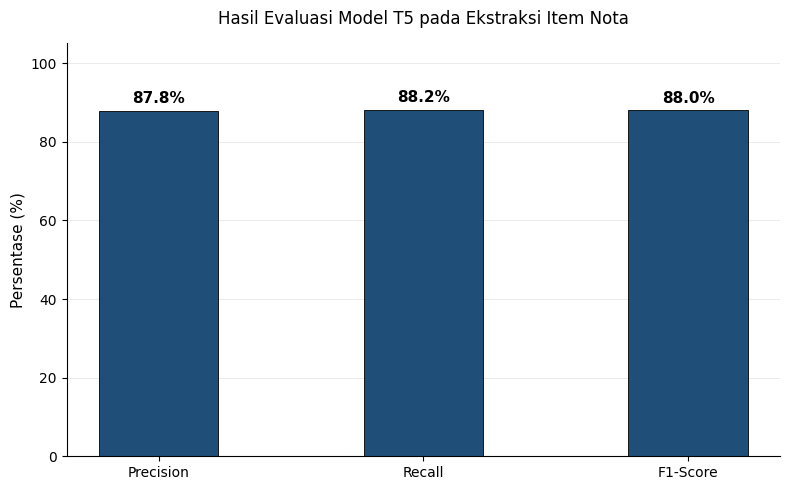


Grafik tersimpan di Drive: grafik_evaluasi_t5.png


In [ ]:
# ============================================================
# CELL I — Evaluasi Parser T5 (Precision, Recall, F1) + Grafik
# ============================================================
!pip install -q datasets transformers sentencepiece matplotlib
import re, json, torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PARSER = "pipluptine/bagi-tagihan-parser"
tok = AutoTokenizer.from_pretrained(PARSER)
mdl = AutoModelForSeq2SeqLM.from_pretrained(PARSER).eval()
PREFIX = "ekstrak nota: "

@torch.no_grad()
def run_parser(text):
    enc = tok(PREFIX + text, return_tensors="pt", max_length=768, truncation=True)
    out = mdl.generate(**enc, max_length=512, num_beams=4, early_stopping=True)
    return tok.decode(out[0], skip_special_tokens=True)

def parse_pred_items(s):
    items = set()
    for m in re.finditer(r'ITEM:\s*(.+?)\s*\|\s*(\d+)\s*\|\s*(\d+)', s):
        price = int(m.group(2))
        if price >= 1000:
            items.add((m.group(1).strip().upper(), price))
    return items

def build_gold_items(gt_json):
    gt = json.loads(gt_json); items = {}; cur_nm = None
    for line in gt.get('valid_line', []):
        cat = line.get('category','')
        words = ' '.join(w.get('text','') for w in line.get('words',[])).strip()
        if cat == 'menu.nm':
            cur_nm = words.upper()
        elif cat in ('menu.price','menu.unitprice') and cur_nm:
            nums = re.sub(r'[^0-9]','',words)
            if nums and int(nums) >= 1000: items[cur_nm] = int(nums)
            cur_nm = None
    return set(items.items())

def build_input(gt_json):
    gt = json.loads(gt_json)
    return ' '.join(w.get('text','').strip() for line in gt.get('valid_line',[])
                    for w in line.get('words',[]) if w.get('text','').strip())

def match_items(pred_items, gold_items):
    tp = 0; matched = set()
    for pname, pprice in pred_items:
        for gname, gprice in gold_items:
            if gprice == pprice and (gname,gprice) not in matched:
                tp += 1; matched.add((gname,gprice)); break
    return tp, len(pred_items)-tp, len(gold_items)-tp

ds = load_dataset("naver-clova-ix/cord-v2", split="test")
print(f"Test set: {len(ds)} sampel\nMemulai evaluasi...")

total_tp = total_fp = total_fn = skipped = 0
for idx, ex in enumerate(ds):
    gold_items = build_gold_items(ex["ground_truth"])
    if not gold_items: skipped += 1; continue
    inp = build_input(ex["ground_truth"])
    if not inp.strip(): skipped += 1; continue
    tp, fp, fn = match_items(parse_pred_items(run_parser(inp[:600])), gold_items)
    total_tp += tp; total_fp += fp; total_fn += fn
    if (idx+1) % 20 == 0: print(f"  [{idx+1}/{len(ds)}] ...")

prec = total_tp/(total_tp+total_fp)*100 if total_tp+total_fp else 0
rec  = total_tp/(total_tp+total_fn)*100 if total_tp+total_fn else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0

print(f"\nPrecision : {prec:.1f}%")
print(f"Recall    : {rec:.1f}%")
print(f"F1-Score  : {f1:.1f}%")

# ---------- GRAFIK ----------
fig, ax = plt.subplots(figsize=(8,5))
labels = ["Precision", "Recall", "F1-Score"]
vals   = [prec, rec, f1]

bars = ax.bar(labels, vals, color="#1f4e79", width=0.45, edgecolor="black", linewidth=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1.2, f"{v:.1f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_ylabel("Persentase (%)", fontsize=11)
ax.set_ylim(0, 105); ax.set_yticks(range(0,101,20))
ax.grid(axis="y", alpha=0.25, linewidth=0.7); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
ax.set_title("Hasil Evaluasi Model T5 pada Ekstraksi Item Nota", fontsize=12, pad=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/grafik_evaluasi_t5.png", dpi=200, facecolor="white", bbox_inches="tight")
plt.show()
print("\nGrafik tersimpan di Drive: grafik_evaluasi_t5.png")